In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('../dataset/housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df_a = df.copy()
df_a = df_a.drop(columns=['ocean_proximity']).dropna()

x = df_a.drop(columns=['median_house_value'])
y = df_a['median_house_value']

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.2, random_state=42)

model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
y_pred_train = model.predict(x_train)

print(f"MAE:  {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R²:   {r2_score(y_test, y_pred):.3f}")

print(f"MAE:  {mean_absolute_error(y_train, y_pred_train):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.2f}")
print(f"R²:   {r2_score(y_train, y_pred_train):.3f}")

MAE:  51254.56
RMSE: 70063.24
R²:   0.632
MAE:  50991.38
RMSE: 68975.54
R²:   0.641


In [ ]:
df_b = df.copy()

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

x = df_b.drop(columns=['median_house_value'])
y = df_b['median_house_value']

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=42)

median = x_train['total_bedrooms'].median()
x_train['total_bedrooms'] = x_train['total_bedrooms'].fillna(median)
x_test['total_bedrooms']  = x_test['total_bedrooms'].fillna(median)

coastal_metros = {
    'Los Angeles':   (-118.24, 34.05),
    'San Diego':     (-117.16, 32.72),
    'San Jose':      (-121.89, 37.34),
    'San Francisco': (-122.42, 37.77),
}

def add_features(df):

    df = df.copy()
    eps = 1e-6

    df['rooms_per_household']      = df['total_rooms'] / (df['households'] + eps )
    df['bedrooms_per_room']        = df['total_bedrooms'] / (df['total_rooms'] + eps )
    df['population_per_household'] = df['population'] / (df['households'] + eps )
    df['income_per_person']        = df['median_income'] / (df['population_per_household'] + eps )

    dists = []
    for _, (city_lon, city_lat) in coastal_metros.items():
        dists.append(np.sqrt(
            (df['longitude'] - city_lon)**2 +
            (df['latitude']  - city_lat)**2
        ))
    df['dist_to_nearest_metro'] = np.min(dists, axis=0)

    df = df.drop(columns=['total_rooms', 'total_bedrooms',
                          'population', 'households'])
    return df

x_train = add_features(x_train)
x_test  = add_features(x_test)

encoder.fit(x_train[['ocean_proximity']])
train_encoded = encoder.transform(x_train[['ocean_proximity']])
test_encoded  = encoder.transform(x_test[['ocean_proximity']])

train_encoded = pd.DataFrame(train_encoded, columns=encoder.get_feature_names_out(['ocean_proximity']), index=x_train.index)
test_encoded  = pd.DataFrame(test_encoded,  columns=encoder.get_feature_names_out(['ocean_proximity']), index=x_test.index)

x_train = x_train.drop(columns=['ocean_proximity']).join(train_encoded)
x_test  = x_test.drop(columns=['ocean_proximity']).join(test_encoded)

model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
y_pred_train = model.predict(x_train)

print(f"MAE:  {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R²:   {r2_score(y_test, y_pred):.3f}")

print(f"MAE:  {mean_absolute_error(y_train, y_pred_train):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.2f}")
print(f"R²:   {r2_score(y_train, y_pred_train):.3f}")


MAE:  47492.50
RMSE: 67626.76
R²:   0.651
MAE:  46093.71
RMSE: 64490.11
R²:   0.689


## Results comparison

| Version | Test R² | Test MAE | Test RMSE | Train R² |
|---|---|---|---|---|
| v1 — Ordinal encoding, raw features, leaky imputation, wrong split | 0.637 | 50,915 | 69,466 | 0.614 |
| v2 — Fixed split, no-leak imputation, one-hot encoding | 0.625 | 50,670 | 70,059 | 0.650 |
| v3 — v2 + ratio features + distance to nearest metro | **0.651** | **47,492** | **67,627** | 0.689 |

## What changed at each step

### v1 → v2: Methodology fixes

Nothing about the features changed here — we fixed how we were handling the data.

- **Fixed the train/test split.** `train_size=0.2` was training on only 20% of the data. Switched to `train_size=0.8`.
- **Removed data leakage in imputation.** The median for `total_bedrooms` NaN values was being computed on the full dataset before splitting, letting test-set information leak into training. Now the median is computed on `x_train` only and applied to both.
- **Switched from `OrdinalEncoder` to `OneHotEncoder` for `ocean_proximity`.** Ordinal encoding invented a fake linear ordering (`<1H OCEAN` = 0, `INLAND` = 1, etc.) that a linear model would try to interpret as a real numeric relationship. One-hot gives each category its own binary column, no fake ordering.
- **Fit the encoder on train only** and applied it to both train and test to prevent category-code mismatches.

R² barely moved because the encoding wasn't the bottleneck — but the model became methodologically correct.

### v2 → v3: Feature engineering

The correlation heatmap showed `total_rooms`, `total_bedrooms`, `population`, and `households` were all strongly correlated with each other (~0.86–0.97). Individually they tell the model roughly the same story: "this block has more stuff because it has more people." We replaced the raw totals with more informative derived features.

**Ratio features** (turning totals into per-unit measures):
- `rooms_per_household` — average dwelling size
- `bedrooms_per_room` — density / dwelling type signal
- `population_per_household` — occupancy
- `income_per_person` — income normalized by household size

**Geographic feature** (turning coordinates into a price-relevant signal):
- `dist_to_nearest_metro` — Euclidean distance to the closest of LA, SD, SJ, or SF. Raw latitude and longitude aren't linearly related to price (California isn't monotonically expensive north-to-south), but distance to a known price anchor is.

**Dropped the four redundant raw totals** after building the ratios. Kept `latitude`/`longitude` because a single "distance to nearest metro" doesn't fully replace them (two houses equidistant from SF can be very different places).

Small numerical safeguard: added `eps = 1e-6` to denominators to prevent division-by-zero without meaningfully distorting the ratios.

## The linear ceiling

Train R² (0.689) and test R² (0.651) are close — the model isn't overfitting, it's *underfitting*. The remaining gap between what we have and what's achievable on this data is a **model capacity** problem, not a features problem. House prices depend non-linearly on income, location, and age, and a linear model can't capture those interactions no matter how well we engineer the inputs.

In [ ]:
from sklearn.linear_model import RidgeCV 
from sklearn.preprocessing import StandardScaler

df_b = df.copy()

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

x = df_b.drop(columns=['median_house_value'])
y = df_b['median_house_value']

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=42)

median = x_train['total_bedrooms'].median()
x_train['total_bedrooms'] = x_train['total_bedrooms'].fillna(median)
x_test['total_bedrooms']  = x_test['total_bedrooms'].fillna(median)

coastal_metros = {
    'Los Angeles':   (-118.24, 34.05),
    'San Diego':     (-117.16, 32.72),
    'San Jose':      (-121.89, 37.34),
    'San Francisco': (-122.42, 37.77),
}

def add_features(df):
    df = df.copy()
    eps = 1e-6

    df['population_per_household'] = df['population'] / (df['households'] + eps)
    df['income_per_person']        = df['median_income'] / (df['population_per_household'] + eps)

    dists = []
    for _, (city_lon, city_lat) in coastal_metros.items():
        dists.append(np.sqrt(
            (df['longitude'] - city_lon)**2 +
            (df['latitude']  - city_lat)**2
        ))
    df['dist_to_nearest_metro'] = np.min(dists, axis=0)

    return df

x_train = add_features(x_train)
x_test  = add_features(x_test)

encoder.fit(x_train[['ocean_proximity']])
train_encoded = encoder.transform(x_train[['ocean_proximity']])
test_encoded  = encoder.transform(x_test[['ocean_proximity']])

train_encoded = pd.DataFrame(train_encoded, columns=encoder.get_feature_names_out(['ocean_proximity']), index=x_train.index)
test_encoded  = pd.DataFrame(test_encoded,  columns=encoder.get_feature_names_out(['ocean_proximity']), index=x_test.index)

x_train = x_train.drop(columns=['ocean_proximity']).join(train_encoded)
x_test  = x_test.drop(columns=['ocean_proximity']).join(test_encoded)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

model = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0])
model.fit(x_train_scaled, y_train)

y_pred = model.predict(x_test_scaled)
y_pred_train = model.predict(x_train_scaled)

print(f"MAE:  {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R²:   {r2_score(y_test, y_pred):.3f}")

print(f"MAE:  {mean_absolute_error(y_train, y_pred_train):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.2f}")
print(f"R²:   {r2_score(y_train, y_pred_train):.3f}")

MAE:  47386.76
RMSE: 66220.03
R²:   0.665
MAE:  46575.02
RMSE: 64832.40
R²:   0.686


In [ ]:
from sklearn.linear_model import RidgeCV 
from sklearn.preprocessing import StandardScaler

df_b = df.copy()

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

x = df_b.drop(columns=['median_house_value'])
y = df_b['median_house_value']

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=42)

median = x_train['total_bedrooms'].median()
x_train['total_bedrooms'] = x_train['total_bedrooms'].fillna(median)
x_test['total_bedrooms']  = x_test['total_bedrooms'].fillna(median)

coastal_metros = {
    'Los Angeles':   (-118.24, 34.05),
    'San Diego':     (-117.16, 32.72),
    'San Jose':      (-121.89, 37.34),
    'San Francisco': (-122.42, 37.77),
}

def add_features(df):
    df = df.copy()
    eps = 1e-6

    # here is the change
    df['rooms_per_household']      = df['total_rooms'] / (df['households'] + eps )
    df['bedrooms_per_room']        = df['total_bedrooms'] / (df['total_rooms'] + eps )
    df['population_per_household'] = df['population'] / (df['households'] + eps )
    df['income_per_person']        = df['median_income'] / (df['population_per_household'] + eps )

    dists = []
    for _, (city_lon, city_lat) in coastal_metros.items():
        dists.append(np.sqrt(
            (df['longitude'] - city_lon)**2 +
            (df['latitude']  - city_lat)**2
        ))
    df['dist_to_nearest_metro'] = np.min(dists, axis=0)

    return df

x_train = add_features(x_train)
x_test  = add_features(x_test)

encoder.fit(x_train[['ocean_proximity']])
train_encoded = encoder.transform(x_train[['ocean_proximity']])
test_encoded  = encoder.transform(x_test[['ocean_proximity']])

train_encoded = pd.DataFrame(train_encoded, columns=encoder.get_feature_names_out(['ocean_proximity']), index=x_train.index)
test_encoded  = pd.DataFrame(test_encoded,  columns=encoder.get_feature_names_out(['ocean_proximity']), index=x_test.index)

x_train = x_train.drop(columns=['ocean_proximity']).join(train_encoded)
x_test  = x_test.drop(columns=['ocean_proximity']).join(test_encoded)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

model = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0])
model.fit(x_train_scaled, y_train)

y_pred = model.predict(x_test_scaled)
y_pred_train = model.predict(x_train_scaled)

print(f"MAE:  {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R²:   {r2_score(y_test, y_pred):.3f}")

print(f"MAE:  {mean_absolute_error(y_train, y_pred_train):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.2f}")
print(f"R²:   {r2_score(y_train, y_pred_train):.3f}")

MAE:  47580.96
RMSE: 67732.12
R²:   0.650
MAE:  46107.22
RMSE: 64300.88
R²:   0.691


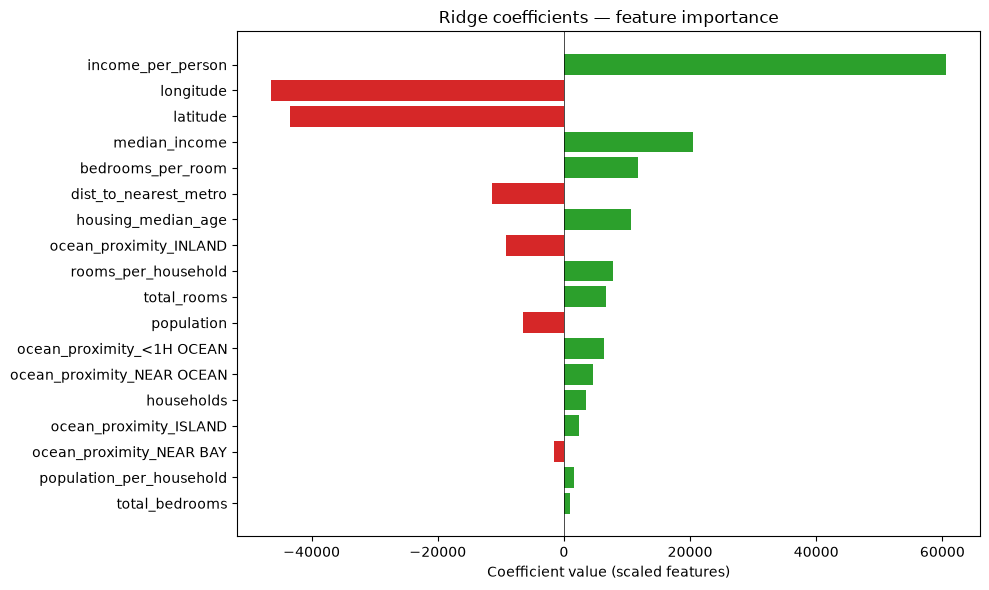

In [10]:
import matplotlib.pyplot as plt

coefs = pd.DataFrame({
    'feature': x_train.columns,
    'coef': model.coef_
})
coefs['abs_coef'] = coefs['coef'].abs()
coefs = coefs.sort_values('abs_coef', ascending=True)

colors = ['#d62728' if c < 0 else '#2ca02c' for c in coefs['coef']]

plt.figure(figsize=(10, 6))
plt.barh(coefs['feature'], coefs['coef'], color=colors)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel('Coefficient value (scaled features)')
plt.title('Ridge coefficients — feature importance')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import RidgeCV 
from sklearn.preprocessing import StandardScaler

df_b = df.copy()

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

x = df_b.drop(columns=['median_house_value'])
y = df_b['median_house_value']

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=42)

median = x_train['total_bedrooms'].median()
x_train['total_bedrooms'] = x_train['total_bedrooms'].fillna(median)
x_test['total_bedrooms']  = x_test['total_bedrooms'].fillna(median)

coastal_metros = {
    'Los Angeles':   (-118.24, 34.05),
    'San Diego':     (-117.16, 32.72),
    'San Jose':      (-121.89, 37.34),
    'San Francisco': (-122.42, 37.77),
}

def add_features(df):
    df = df.copy()
    eps = 1e-6

    df['rooms_per_household']      = df['total_rooms'] / (df['households'] + eps )
    df['bedrooms_per_room']        = df['total_bedrooms'] / (df['total_rooms'] + eps )
    df['population_per_household'] = df['population'] / (df['households'] + eps )
    df['income_per_person']        = df['median_income'] / (df['population_per_household'] + eps )

    dists = []
    for _, (city_lon, city_lat) in coastal_metros.items():
        dists.append(np.sqrt(
            (df['longitude'] - city_lon)**2 +
            (df['latitude']  - city_lat)**2
        ))
    df['dist_to_nearest_metro'] = np.min(dists, axis=0)
    df = df.drop(columns=['total_rooms', 'total_bedrooms','population', 'households']) # here is the change

    return df

x_train = add_features(x_train)
x_test  = add_features(x_test)

encoder.fit(x_train[['ocean_proximity']])
train_encoded = encoder.transform(x_train[['ocean_proximity']])
test_encoded  = encoder.transform(x_test[['ocean_proximity']])

train_encoded = pd.DataFrame(train_encoded, columns=encoder.get_feature_names_out(['ocean_proximity']), index=x_train.index)
test_encoded  = pd.DataFrame(test_encoded,  columns=encoder.get_feature_names_out(['ocean_proximity']), index=x_test.index)

x_train = x_train.drop(columns=['ocean_proximity']).join(train_encoded)
x_test  = x_test.drop(columns=['ocean_proximity']).join(test_encoded)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

model = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0])
model.fit(x_train_scaled, y_train)

y_pred = model.predict(x_test_scaled)
y_pred_train = model.predict(x_train_scaled)

print(f"MAE:  {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R²:   {r2_score(y_test, y_pred):.3f}")

print(f"MAE:  {mean_absolute_error(y_train, y_pred_train):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.2f}")
print(f"R²:   {r2_score(y_train, y_pred_train):.3f}")

MAE:  47480.01
RMSE: 67616.02
R²:   0.651
MAE:  46088.64
RMSE: 64490.62
R²:   0.689


## Results comparison

| Version | Feature strategy | Test R² | Test MAE |
|---|---|---|---|
| **v4** | **Raw correlated totals kept + distance + income_per_person + scaling** | **0.665** | **47,387** |
| v5 | Everything combined (raw totals + all ratios + distance) | 0.650 | 47,581 |
| v5b | v5 with noisy features dropped after inspecting coefficients | 0.651 | 47,480 |

### v4: Trusting Ridge with collinear data

The correlation heatmap showed `total_rooms`, `total_bedrooms`, `population`, and `households` were all strongly correlated (~0.86–0.97). Instead of manually dropping columns, we let Ridge handle the collinearity through regularization.

We kept the four correlated raw totals, added two engineered features (`income_per_person` and `dist_to_nearest_metro` — Euclidean distance to the closest of LA, SD, SJ, or SF), one-hot encoded `ocean_proximity`, scaled everything with `StandardScaler`, and used `RidgeCV` to auto-select the regularization strength.

Result: **R² = 0.665.** Ridge shrunk the coefficients of the redundant totals, stabilized the fight between correlated pairs, and kept all the available information.

### v5: Combining strategies

We added the four ratio features (`rooms_per_household`, `bedrooms_per_room`, `population_per_household`, `income_per_person`) on top of the raw totals — everything in the model.

Result: R² dropped to 0.650. Combining strategies made the model *worse* — the ratios and their source columns overlapped enough that even Ridge couldn't extract more signal.

### v5b: Pruning noise features

We looked at Ridge's coefficient plot and dropped the features with near-zero coefficients.

Result: R² = 0.651. Essentially unchanged — Ridge had already neutralized those features on its own. Manual dropping and Ridge shrinkage converge on the same outcome.

## Feature importance insights (from Ridge coefficients)

Reading the coefficients told us more than the R² alone:

1. **`income_per_person` was the single strongest predictor** — the engineered feature beat every raw column, including `median_income` itself.
2. **`dist_to_nearest_metro` was strongly negative** — farther from a metro = cheaper. The engineered geographic feature worked exactly as designed.
3. **`longitude` and `latitude` had huge coefficients** but this is the coordinate system talking — the model uses them jointly with `dist_to_nearest_metro` to fit geography.
4. **`ocean_proximity_INLAND` was negative**, coastal categories positive — captures the California coast premium.
5. **The redundant raw totals** (`total_bedrooms`, `households`, `population_per_household`) landed near zero — Ridge silenced them automatically.